In [2]:
from typing import Dict, List, Union, Tuple
import dolfin as df
import numpy as np
import matplotlib.pyplot as plt
import os
import time


constants

In [3]:

# Define some constants
DIRICHLET = "Dirichlet"
NEUMANN = "Neumann"
ROBIN = "Robin"
INTERVAL = "Interval"
RECTANGLE = "Rectangle"
HEAT_EQUATION_1D = "1d"
HEAT_EQUATION_2D = "2d"
DEGREE = "degree"
BASIS_FUNCTIONS = "phi"
NUM_TIME_STEPS = "num_time_steps"
ODE_SOLVER = "theta"
DX = "dx"
DS = "ds"
TIME_DEPENDENT = "time_dependent"
TIME_INDEPENDENT = "time_independent"
CONSTANT = "constant"
NUM_DOMAIN = "num_domain"
NUM_INITIAL = "num_initial"
NUM_BOUNDARY = "num_boundary"
NUM_NEURONS = "num_neurons"
NUM_HIDDEN_LAYER = "num_hidden_layer"
ACTIVATION = "activation"
INITIALIZER = "initializer"
OPTIMIZER = "optimizer"
LEARNING_RATE = "learning_rate"
LOSS_WEIGHTS = "loss_weights"
EPOCHS = "epochs"
ALL = "all"
TOP_BOTTOM = "TopBottom"
LEFT_RIGHT = "LeftRight"
NX = "nx"
NY = "ny"
EXACT = "exact"
FEM = "fem"
PINN = "pinn"

# Dict mapping the different test problems to the different domain types
TEST_PROBLEM_TO_DOMAIN_DICT = {
    HEAT_EQUATION_1D: INTERVAL,
    HEAT_EQUATION_2D: RECTANGLE,
}


FEM --> boundary

In [4]:

BOUNDARY_EPS = 1e-3


class Boundary:
    """
    Class for holding subdomain subclasses that specifies which points belong to which part of the boundary for FEM.
    """

    def __init__(self, domain_type: str, boundary_type: str) -> None:
        """
        Constructor of this class.
        Will be called when an object is created from this class and
        allows the class to initialize the attributes of the class.

        :param domain_type:         Name of the domain type (e.g. interval or rectangle).
        :param boundary_type:       Name of the part of the boundary.
        """
        self.boundary = self.BOUNDARY_TYPE_DICT[domain_type][boundary_type]()

    class BoundaryAll(df.SubDomain):
        def inside(self, x, on_boundary):
            return on_boundary

    class RectangleLeftRight(df.SubDomain):
        def inside(self, x, on_boundary):
            return on_boundary and (df.near(x[0], 0, BOUNDARY_EPS) or df.near(x[0], 1, BOUNDARY_EPS))

    class RectangleTopBottom(df.SubDomain):
        def inside(self, x, on_boundary):
            return on_boundary and (df.near(x[1], 0, BOUNDARY_EPS) or df.near(x[1], 1, BOUNDARY_EPS))


    # Dicts holding functions for different domain types and parts of the boundary
    BOUNDARY_INTERVAL_DICT = {
        ALL: BoundaryAll
    }

    BOUNDARY_RECTANGLE_DICT = {
        ALL: BoundaryAll,
        TOP_BOTTOM: RectangleTopBottom,
        LEFT_RIGHT: RectangleLeftRight,
    }

    BOUNDARY_TYPE_DICT = {
        INTERVAL: BOUNDARY_INTERVAL_DICT,
        RECTANGLE: BOUNDARY_RECTANGLE_DICT,
    }


FEM --> expression

In [6]:


class Expression:
    """
    Class for representing user-defined expressions (with regard to the time-stepping loop).
    """

    def __init__(self, math_str: Union[str, float], expression_type: str, t: float = None, degree: int = None) -> None:
        """
        Constructor of this class.
        Will be called when an object is created from this class and
        allows the class to initialize the attributes of the class.

        :param math_str:            String expression.
        :param expression_type:     Determines whether the expression is time dependent, time independent or constant.
        :param t:                   Value of the time variable.
        :param degree:              Degree of the element.
        """
        self.math_str = math_str
        self.expression_type = expression_type
        self.t = t
        self.degree = degree

        # Define two expressions (for single-step methods) per class instance for time-stepping loop
        # In general, N-step methods need N + 1 expressions
        if self.expression_type == TIME_DEPENDENT:
            self.expression = df.Expression(self.math_str, t=self.t, degree=self.degree)
            self.expression2 = df.Expression(self.math_str, t=self.t, degree=self.degree)
        elif self.expression_type == TIME_INDEPENDENT:
            self.expression = df.Expression(self.math_str, degree=self.degree)
            self.expression2 = self.expression
        elif self.expression_type == CONSTANT:
            self.expression = df.Constant(self.math_str)
            self.expression2 = self.expression
        else:
            raise ValueError("No valid expression type")


def test_problem_1d():
    """
    Contains the inhomogeneity of the heat equation, the initial condition,
    the inhomogeneities of the boundary conditions and the solution
    of the 1D test problem, see Section 5.1.

    :return:    Data of the test problem as expressions or dict with key part of boundary and expressions as values.
    """
    degree = 2

    f = Expression(0, expression_type=CONSTANT)

    initial = Expression(
        f"sin(2*{np.pi}*x[0])",
        expression_type=TIME_INDEPENDENT, degree=degree)


    dirichlet = {
        (0, ALL): Expression(0, expression_type=CONSTANT)
    }

    solution = Expression(f"exp(-4*{np.pi * np.pi}*t)*sin(2*{np.pi}*x[0])",
                          expression_type=TIME_DEPENDENT, t=0, degree=degree)

    return f, initial, dirichlet, {}, {}, {}, solution


def test_problem_2d():
    """
    Contains the inhomogeneity of the heat equation, the initial condition,
    the inhomogeneities of the boundary conditions and the solution
    of the 2D test problem, see Section 5.2.

    :return:    Data of the test problem as expressions or dict with key part of boundary and expressions as values.
    """
    degree = 2

    pi_squared = np.pi * np.pi

    f = Expression(
        f"4*{pi_squared}*exp(-4*{pi_squared}*t)*cos(2*{np.pi}*x[0])*cos(2*{np.pi}*x[1])",
        expression_type=TIME_DEPENDENT, t=0, degree=degree)

    initial = Expression(
        f"cos(2*{np.pi}*x[0])*cos(2*{np.pi}*x[1])",
        expression_type=TIME_INDEPENDENT, degree=degree)

    dirichlet = {
        (0, LEFT_RIGHT): Expression(
            f"exp(-4*{pi_squared}*t)*cos(2*{np.pi}*x[1])",
            expression_type=TIME_DEPENDENT, t=0, degree=degree
        )
    }

    neumann = {
        (1, TOP_BOTTOM): Expression(0, expression_type=CONSTANT)
    }

    solution = Expression(f"exp(-4*{pi_squared}*t)*cos(2*{np.pi}*x[0])*cos(2*{np.pi}*x[1])",
                          expression_type=TIME_DEPENDENT, t=0, degree=degree)

    return f, initial, dirichlet, neumann, {}, {}, solution


# Dicts holding the data of the different test problems for different domain types
EXPRESSION_INTERVAL_DICT = {
    HEAT_EQUATION_1D: test_problem_1d
}

EXPRESSIONS_RECTANGLE_DICT = {
    HEAT_EQUATION_2D: test_problem_2d
}

EXPRESSIONS_TYPE_DICT = {
    INTERVAL: EXPRESSION_INTERVAL_DICT,
    RECTANGLE: EXPRESSIONS_RECTANGLE_DICT,
}


FEM --> mesh

In [7]:

def set_mesh_interval(args: Dict[str, int]) -> df.Mesh:
    """
    Creates a mesh of the interval with endpoints 0 and 1.
    The total number of intervals will be NX and the total number of vertices will be NX + 1.

    :param args:    Dict with key NX and number of cells as value.
    :return:        The mesh.
    """
    return df.UnitIntervalMesh(args[NX])


def set_mesh_rectangle(args: Dict[str, int]) -> df.Mesh:
    """
    Creates a triangular mesh of the rectangle with bottom left corner [0, 0] and top right corner [1, 1].
    The total number of triangles will be 2 * NX * NY and the total number of vertices will be (NX + 1) * (NY + 1).
    
    :param args:    Dict with keys NX and NY with number of cells in horizontal and vertical direction as values.
    :return:        The mesh.
    """
    return df.UnitSquareMesh(args[NX], args[NY])


# Dict holding mesh functions for different domain types
DOMAIN_TYPE_DICT = {
    INTERVAL: set_mesh_interval,
    RECTANGLE: set_mesh_rectangle,
}


FEM --> solver

In [8]:

class FEMSolver:
    """
    Class for solving the heat equation with the finite element method (FEM).
    """

    def __init__(self, test_problem_str: str, T: float) -> None:
        """
        Constructor of this class.
        Will be called when an object is created from this class and
        allows the class to initialize the attributes of the class.

        :param test_problem_str:    Name of the test problem.
        :param T:                   Final time.
        """
        self.test_problem_str = test_problem_str
        self.T = T
        self.domain_type = TEST_PROBLEM_TO_DOMAIN_DICT[self.test_problem_str]

        self.f = None
        self.initial = None
        self.dirichlet = None
        self.neumann = None
        self.robin_rho = None
        self.robin_g = None
        self.solution = None

        self.boundaries_assignment_dict = None
        self.num_dirichlet_sectors = None
        self.num_neumann_sectors = None
        self.num_robin_sectors = None

        self.boundary_types = None

    def setup_test_problem(self) -> None:
        """
        Initializing the inhomogeneity of the heat equation, the initial condition,
        the inhomogeneities of the boundary conditions and the solution.

        :return:    None
        """
        self.f, self.initial, self.dirichlet, self.neumann, self.robin_rho, self.robin_g, self.solution = \
            EXPRESSIONS_TYPE_DICT[self.domain_type][self.test_problem_str]() 

        # Assign the different parts of the boundary to the different boundary types
        self.boundaries_assignment_dict = {
            DIRICHLET: list(self.dirichlet.keys()),
            NEUMANN: list(self.neumann.keys()),
            ROBIN: list(self.robin_rho.keys())
        }
        self.num_dirichlet_sectors = 0 if self.dirichlet is None else len(self.boundaries_assignment_dict[DIRICHLET])
        self.num_neumann_sectors = 0 if self.neumann is None else len(self.boundaries_assignment_dict[NEUMANN])
        self.num_robin_sectors = 0 if self.robin_rho is None else len(self.boundaries_assignment_dict[ROBIN])

    def set_boundary_types(self) -> None:
        """
        Defines python functions for the different parts of the boundary.
        The functions should return booleans depending whether a point is on the boundary or not.

        :return:    None
        """
        self.boundary_types = {
            (key, sector): Boundary(self.domain_type, sector).boundary
            for (key, sector) in (
                self.boundaries_assignment_dict[DIRICHLET] +
                self.boundaries_assignment_dict[NEUMANN] +
                self.boundaries_assignment_dict[ROBIN]
            )
        }

    def set_mesh(self, mesh_resolution_args: Dict[str, int]) -> df.mesh:
        """
        Defines the computational mesh.

        :param mesh_resolution_args:    Dict with keys NX (and NY in 2D) with number of cells as value(s).
        :return:                        The mesh.
        """
        return DOMAIN_TYPE_DICT[self.domain_type](mesh_resolution_args)

    @staticmethod
    def set_function_space(mesh: df.Mesh, function_space_args: Dict[str, Union[int, str]]) -> df.FunctionSpace:
        """
        Defines the finite element function space.

        :param mesh:                    The mesh.
        :param function_space_args:     Dict with keys BASIS_FUNCTIONS and DEGREE with
                                        specification of the element family (e. g. Lagrange) and
                                        the degree of the element as values.
        :return:                        Finite element function space.
        """
        return df.FunctionSpace(
            mesh,
            function_space_args[BASIS_FUNCTIONS],
            function_space_args[DEGREE]
        )

    def set_boundary_conditions_and_measures(
        self,
        mesh: df.Mesh
    ) -> Tuple[Dict[Tuple[int, str], Boundary], List[df.Measure]]:
        """
        Defining markers for the different parts of the boundary and
        splitting the boundary integral into parts using the markers.
        
        :param mesh:        The mesh.
        :return:            Dict with keys (marker, part of boundary) and
                            Boundary class instance as values and
                            list of measures.
        """
        boundary_markers = df.MeshFunction("size_t", mesh, mesh.topology().dim() - 1)
        boundary_markers.set_all(0)

        boundary_conditions = self.boundary_types.copy()
        for key_tuple in boundary_conditions:
            boundary_conditions[key_tuple].mark(boundary_markers, key_tuple[0])

        # Define the measures in terms of the boundary markers
        dx = df.Measure(DX, mesh, subdomain_data=boundary_markers)

        if self.num_neumann_sectors + self.num_robin_sectors > 0:
            ds = df.Measure(DS, mesh, subdomain_data=boundary_markers)
        else:
            ds = None

        return boundary_conditions, [dx, ds]

    def _define_variational_problem(
        self,
        measures: List[df.Measure],
        function_space: df.FunctionSpace,
        time_discretization_args: Dict[str, int]
    ) -> Tuple[List[df.Function], List[df.Function]]:
        """
        Internal function for defining the variational problem.
        For time discretization we use the θ-method, where as
            θ = 0:      explicit Euler method,
            θ = 0.5:    Crank-Nicholson method,
            θ = 1:      implicit Euler method.
        See [Dzi10, Abschnitt 5.7].

        :param measures:                    List of measures.
        :param function_space:              Finite element function space.
        :param time_discretization_args:    Dict with keys NUM_TIME_STEPS and ODE_SOLVER with
                                            number of time steps and ODE solver (θ) as values.
        :return:                            Left and right-hand side of the variational problem and
                                            numerical solutions at the current and previous time steps.
        """
        dt = self.T / time_discretization_args[NUM_TIME_STEPS]      # Time step size
        theta = time_discretization_args[ODE_SOLVER]
        [dx, ds] = measures

        # Define initial function
        u_n = df.interpolate(self.initial.expression, function_space)

        # Define variational problem
        u = df.TrialFunction(function_space)
        v = df.TestFunction(function_space)

        left_hand_side = u * v * dx + dt * theta * df.dot(df.grad(u), df.grad(v)) * dx
        right_hand_side = u_n * v * dx - dt * (1 - theta) * df.dot(df.grad(u_n), df.grad(v)) * dx

        right_hand_side += dt * theta * self.f.expression * v * dx + \
                                dt * (1 - theta) * self.f.expression2 * v * dx

        if self.num_neumann_sectors > 0:
            for key_tuple in self.boundaries_assignment_dict[NEUMANN]:
                right_hand_side += dt * theta * self.neumann[key_tuple].expression * v * ds(key_tuple[0]) + \
                     dt * (1 - theta) * self.neumann[key_tuple].expression2 * v * ds(key_tuple[0])

        if self.num_robin_sectors > 0:
            for key_tuple in self.boundaries_assignment_dict[ROBIN]:
                left_hand_side += dt * theta * self.robin_rho[key_tuple].expression * u * v * ds(key_tuple[0])
                right_hand_side -= dt * (1 - theta) * \
                                   self.robin_rho[key_tuple].expression2 * u_n * v * ds(key_tuple[0])
                right_hand_side += dt * theta * self.robin_g[key_tuple].expression * v * ds(key_tuple[0]) + \
                     dt * (1 - theta) * self.robin_rho[key_tuple].expression2 * v * ds(key_tuple[0])

        return [left_hand_side, right_hand_side], [df.Function(function_space), u_n]

    def _solve_variational_problem(
        self,
        variational_problem: List[df.Function],
        approx_functions: List[df.Function],
        boundary_conditions: Dict[Tuple[int, str], Boundary],
        function_space: df.FunctionSpace,
        time_discretization_args: Dict[str, int]
    ) -> Tuple[np.array, np.array]:
        """
        Internal function for solving the variational problem in the time-stepping loop.

        :param variational_problem:         Left and right-hand side of the variational problem.
        :param approx_functions:            Numerical solutions at the current and previous time steps.
        :param boundary_conditions:         Dict with keys (marker, part of boundary) and
                                            Boundary class instance as values.
        :param function_space:              Finite element function space.
        :param time_discretization_args:    Dict with keys NUM_TIME_STEPS and ODE_SOLVER with
                                            number of time steps and ODE solver (θ) as values.
        :return:                            Numerical solutions and different time steps from the numerical solution
                                            as numpy arrays.
        """
        [u, u_n] = approx_functions

        # Initialize solution and time-values array
        solution_data = np.zeros((time_discretization_args[NUM_TIME_STEPS] + 1, function_space.dim()))
        solution_data[0, :] = np.array(
            df.interpolate(self.initial.expression, function_space).vector()
        )
        time_values_data = np.zeros(time_discretization_args[NUM_TIME_STEPS] + 1)

        # Time-stepping
        dt = self.T / time_discretization_args[NUM_TIME_STEPS]
        t = t_n = 0
        for time_step in range(time_discretization_args[NUM_TIME_STEPS]):

            # Update current time
            t += dt

            # Update time in time-dependent expressions
            if self.solution is not None:
                self.solution.expression.t = t
                self.solution.expression2.t = t_n

            if self.f.expression_type == TIME_DEPENDENT:
                self.f.expression.t = t
                self.f.expression2.t = t_n

            if self.num_dirichlet_sectors > 0:
                for key_tuple in self.boundaries_assignment_dict[DIRICHLET]:
                    if self.dirichlet[key_tuple].expression_type == TIME_DEPENDENT:
                        self.dirichlet[key_tuple].expression.t = t
                        self.dirichlet[key_tuple].expression2.t = t_n

            if self.num_neumann_sectors > 0:
                for key_tuple in self.boundaries_assignment_dict[NEUMANN]:
                    if self.neumann[key_tuple].expression_type == TIME_DEPENDENT:
                        self.neumann[key_tuple].expression.t = t
                        self.neumann[key_tuple].expression2.t = t_n

            if self.num_robin_sectors > 0:
                for key_tuple in self.boundaries_assignment_dict[ROBIN]:
                    if self.robin_rho[key_tuple].expression_type == TIME_DEPENDENT:
                        self.robin_rho[key_tuple].expression.t = t
                        self.robin_rho[key_tuple].expression2.t = t_n
                    if self.robin_g[key_tuple].expression_type == TIME_DEPENDENT:
                        self.robin_g[key_tuple].expression.t = t
                        self.robin_g[key_tuple].expression2.t = t_n

            # Set Dirichlet boundary conditions and compute solution
            if self.num_dirichlet_sectors > 0:
                dirichlet_bcs = []
                for key_tuple in self.boundaries_assignment_dict[DIRICHLET]:
                    dirichlet_bcs.append(
                        df.DirichletBC
                            (
                                function_space,
                                self.dirichlet[key_tuple].expression,
                                boundary_conditions[key_tuple]
                            )
                    )
                df.solve(variational_problem[0] == variational_problem[1], u, dirichlet_bcs)
            else:
                df.solve(variational_problem[0] == variational_problem[1], u)

            # Save solution and time-values for current time
            solution_data[time_step + 1, :] = np.array(u.vector())
            time_values_data[time_step + 1] = t

            # Compute inf-error at vertices
            if self.solution is not None:
                exact_current = df.interpolate(self.solution.expression, function_space)
                error_current = np.abs(np.array(exact_current.vector()) - np.array(u.vector())).max()
                print(f"t = {t}, error = {error_current}")
            else:
                print(f"t = {t}")

            # Update previous solution
            u_n.assign(u)
            t_n = t

        return solution_data, time_values_data

    def solve(
        self,
        boundary_conditions: Dict[Tuple[int, str], Boundary],
        function_space: df.FunctionSpace,
        measures: List[df.Measure],
        time_discretization_args: Dict[str, int]
    ) -> Tuple[np.array, np.array]:
        """
        Defines and solves the variational problem in the time-stepping loop.
        
        :param boundary_conditions:         Dict with keys (marker, part of boundary) and
                                            Boundary class instance as values.
        :param function_space:              Finite element function space.
        :param measures:                    List of measures.
        :param time_discretization_args:    Dict with keys NUM_TIME_STEPS and ODE_SOLVER with
                                            number of time steps and ODE solver (θ) as values.
        :return:                            Numerical solutions and different time steps from the numerical solution
                                            as numpy arrays.
        """
        variational_problem, approx_functions = self._define_variational_problem(
            measures, function_space, time_discretization_args
        )
        return self._solve_variational_problem(
            variational_problem, approx_functions, boundary_conditions, function_space, time_discretization_args
        )


test_1D

In [58]:
#final time
T = 0.1

# Start timer
start_fem = time.time()

# Initialize FEM solver class instance
solver_fem = FEMSolver(
    test_problem_str=HEAT_EQUATION_1D,
    T=T
)
solver_fem.setup_test_problem()
solver_fem.set_boundary_types()

# Create mesh and define function space
mesh = solver_fem.set_mesh(
    {NX: 25}
)   # nx*2 = num_space_steps -> h = 1 / (2*nx)
function_space = solver_fem.set_function_space(
    mesh, {BASIS_FUNCTIONS: "Lagrange", DEGREE: 2}
)

# Define boundary conditions
bcs, measures = solver_fem.set_boundary_conditions_and_measures(mesh)

# Compute solution
solution_fem, time_values_data = solver_fem.solve(bcs, function_space, measures, {NUM_TIME_STEPS: 100, ODE_SOLVER: 1})

# Determine computational time
end_fem = time.time()
timer_fem = end_fem - start_fem

t = 0.001, error = 0.0007298582687786936
t = 0.002, error = 0.001402561699003102
t = 0.003, error = 0.0020225721073583447
t = 0.004, error = 0.0025929719986028665
t = 0.005, error = 0.00311665523254101
t = 0.006, error = 0.0035963658902049556
t = 0.007, error = 0.0040347062726390215
t = 0.008, error = 0.004434143759916909
t = 0.009000000000000001, error = 0.004797017332802467
t = 0.010000000000000002, error = 0.005125543792101173
t = 0.011000000000000003, error = 0.005421823689812366
t = 0.012000000000000004, error = 0.005687846985051981
t = 0.013000000000000005, error = 0.005925498437133414
t = 0.014000000000000005, error = 0.006136562747650398
t = 0.015000000000000006, error = 0.006322729462878818
t = 0.016000000000000007, error = 0.006485597647321595
t = 0.017000000000000008, error = 0.0066266803387381445
t = 0.01800000000000001, error = 0.006747408794545662
t = 0.01900000000000001, error = 0.006849136539042899
t = 0.02000000000000001, error = 0.006933143220487825
t = 0.021000000000

In [36]:
a = function_space.tabulate_dof_coordinates()
np.savez('function_space_1d.npz', a)

In [59]:
# plotting comparision of eaxct, FEM and PINNs solution

def plot_1d_graph(
    solution_dict: Dict[str, np.array],
    function_space: df.FunctionSpace,
    time_mesh: np.array,
    levels: List[int],
    
) -> None:
    """
    Plots exact and numerical solutions of 1D heat equation versus x-coordinate as lines for different times t.

    :param solution_dict:       Dict of exact and numerical solutions as numpy arrays.
    :param function_space:      Finite element function space from FEM solution.
    :param time_mesh:           Different time steps from FEM solution as numpy array.
    :param levels:              List of time indexes to plot the solutions.
    :return:                    None
    """
    # Define labels and linestyles for the solutions
    name_dict = {EXACT: "Exact", FEM: "FEM", PINN: "PINN"}
    linestyle_dict = {EXACT: "solid", FEM: "dashed", PINN: "dashdot"}

    # Compute min and max values of the solutions for setting the y-limits
    solution_min = np.min(list(solution_dict.values()))
    solution_max = np.max(list(solution_dict.values()))

    # Time-stepping
    for step in levels:

        # Iterate over the different solutions
        plt.clf()
        for name, solution in solution_dict.items():
            solution_function = df.Function(function_space)
            solution_function.vector().set_local(solution[step, :])

            # Plot solution
            df.plot(
                solution_function,
                title=f"$t = {time_mesh[step]:.2f}$",
                label=name_dict[name],
                linestyle=linestyle_dict[name],
            )

        # Finalize and save the plot
        plt.ylim((solution_min - 0.2, solution_max + 0.2))
        plt.xlabel(r"$x$")
        plt.ylabel(r"$u$")
        plt.legend()
    plt.show()
    
    
    
sol = np.load('/home/hpcs_rnd/RAVINDRA_IISc/heat_equation/data_1d/solution_all_1d.npz')
exact_solution = sol['exact_solution']
solution_pinn  = sol['solution_pinn']
solution_fem   = sol['solution_fem']

plot_1d_graph(
        {
            EXACT: exact_solution,
            FEM: solution_fem,
            PINN: solution_pinn
        },
        function_space,
        time_values_data,
        [0,10,20,30,40,50,60,70,80,90,100],
        
    )    

test_2D

In [9]:
#final time
T = 0.1

# Start timer
start_fem = time.time()

# Initialize FEM solver class instance
solver_fem = FEMSolver(
    test_problem_str=HEAT_EQUATION_2D,
    T=T
)
solver_fem.setup_test_problem()
solver_fem.set_boundary_types()

# Create mesh and define function space
mesh = solver_fem.set_mesh(
    {NX: 25, NY: 25}
)   # nx = ny = 25 equals h = 0.05656854249492385 with mesh.hmax() -> see Table 3
function_space = solver_fem.set_function_space(
    mesh, {BASIS_FUNCTIONS: "Lagrange", DEGREE: 2}
)

# Define boundary conditions
bcs, measures = solver_fem.set_boundary_conditions_and_measures(mesh)

# Compute solution
solution_fem, time_values_data = solver_fem.solve(bcs, function_space, measures, {NUM_TIME_STEPS: 100, ODE_SOLVER: 1})

# Determine computational time
end_fem = time.time()
timer_fem = end_fem - start_fem

Solving linear variational problem.
t = 0.001, error = 0.0007684084149398585
Solving linear variational problem.
t = 0.002, error = 0.0013847826855820644
Solving linear variational problem.
t = 0.003, error = 0.0019283879050936426
Solving linear variational problem.
t = 0.004, error = 0.002407227710548021
Solving linear variational problem.
t = 0.005, error = 0.0028270760863225997
Solving linear variational problem.
t = 0.006, error = 0.003193210283616521
Solving linear variational problem.
t = 0.007, error = 0.003510497027698567
Solving linear variational problem.
t = 0.008, error = 0.0037834268791326897
Solving linear variational problem.
t = 0.009000000000000001, error = 0.004016142101297193
Solving linear variational problem.
t = 0.010000000000000002, error = 0.0042124607350507715
Solving linear variational problem.
t = 0.011000000000000003, error = 0.004375897888377223
Solving linear variational problem.
t = 0.012000000000000004, error = 0.004509685025326227
Solving linear variati

In [11]:
a = function_space.tabulate_dof_coordinates()
np.savez('function_space_2d.npz', a)

In [14]:
function_space.dim()

2601

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import dolfin as df  # Assuming df is used for finite element operations

from typing import Dict, List

EXACT = 'exact'
FEM = 'fem'
PINN = 'pinn'

def plot_2d_heatmap(
    solution_dict: Dict[str, np.array],
    function_space: df.FunctionSpace,
    time_mesh: np.array,
    levels: List[int],
    folder_path: str  # Added parameter for saving the plots
) -> None:
    """
    Plots exact and numerical solutions of 2D heat equation as a 2D heatmap for different times t.

    :param solution_dict:       Dict of exact and numerical solutions as numpy arrays.
    :param function_space:      Finite element function space from FEM solution.
    :param time_mesh:           Different time steps from FEM solution as numpy array.
    :param levels:              List of time indexes to plot the solutions.
    :param folder_path:         Location for saving the figures to.
    :return:                    None
    """
    # Define labels for the solutions
    name_dict = {EXACT: "$u$", FEM: r"$u_{h,\tau}$", PINN: r"$u_{\theta}$"}

    # Compute min and max values of the solutions for setting the color bar limits
    solution_min = np.min(list(solution_dict.values()))
    solution_max = np.max(list(solution_dict.values()))

    # Time-stepping and iterating over the different solutions
    for name, solution in solution_dict.items():
        for step in levels:
            solution_function = df.Function(function_space)
            solution_function.vector().set_local(solution[step, :])

            # Plot solution
            plt.clf()
            heatmap = df.plot(
                solution_function,
                title=f"$t = {time_mesh[step]:.2f}$",
                cmap="turbo",
                vmin=solution_min,
                vmax=solution_max
            )

            # Add colorbar and labels
            plt.colorbar(heatmap, label=name_dict[name])
            plt.xlabel(r"$x$")
            plt.ylabel(r"$y$")
            
            # Save the plot
            plt.savefig(f"{folder_path}/heatmap_{name}_{step}.png")



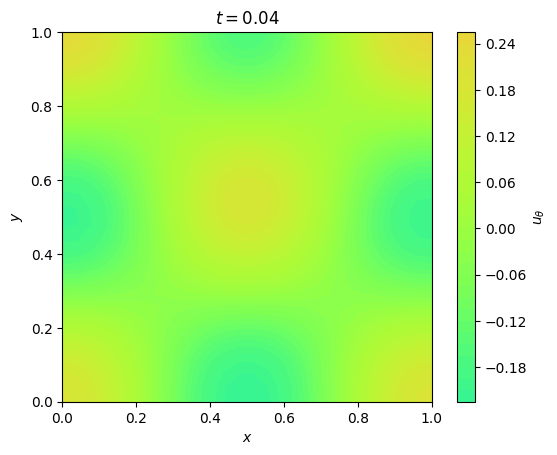

In [12]:
sol = np.load('/home/hpcs_rnd/RAVINDRA_IISc/heat_equation/data_2d/solution_all_2d.npz')
exact_solution = sol['exact_solution']
solution_pinn  = sol['solution_pinn']
solution_fem   = sol['solution_fem']

plot_2d_heatmap(
    {
        EXACT: exact_solution,
        FEM: solution_fem,
        PINN: solution_pinn
    },
    function_space,
    time_values_data,
    [40],
    '/home/hpcs_rnd/RAVINDRA_IISc/heat_equation/plot_2d'
)


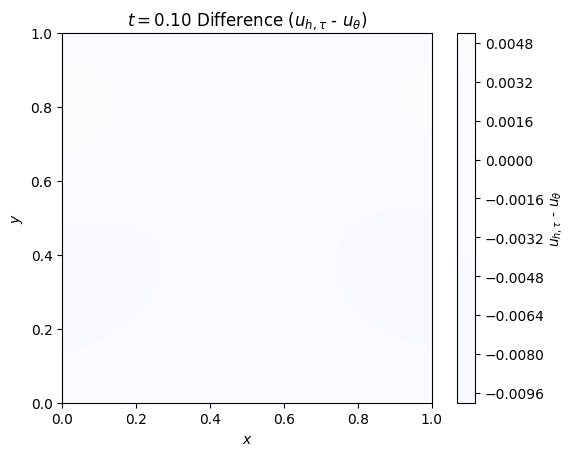

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import dolfin as df
from typing import Dict, List

EXACT = 'exact'
FEM = 'fem'
PINN = 'pinn'

def plot_2d_heatmap(
    solution_dict: Dict[str, np.array],
    function_space: df.FunctionSpace,
    time_mesh: np.array,
    levels: List[int],
    folder_path: str  # Added parameter for saving plots
) -> None:
    """
    Plots exact and numerical solutions of 2D heat equation as a 2D heatmap for different times t.

    :param solution_dict:       Dict of exact and numerical solutions as numpy arrays.
    :param function_space:      Finite element function space from FEM solution.
    :param time_mesh:           Different time steps from FEM solution as numpy array.
    :param levels:              List of time indexes to plot the solutions.
    :param folder_path:         Location for saving the figures to.
    :return:                    None
    """
    # Define labels for the solutions
    name_dict = {EXACT: "$u$", FEM: r"$u_{h,\tau}$", PINN: r"$u_{\theta}$"}

    # Compute min and max values of the solutions for setting the color bar limits
    solution_min = np.min(list(solution_dict.values()))
    solution_max = np.max(list(solution_dict.values()))

    # Compute differences
    diff_exact_pinn = solution_dict[EXACT] - solution_dict[PINN]
    diff_fem_pinn = solution_dict[FEM] - solution_dict[PINN]

    # Time-stepping and iterating over the different solutions
    for name, solution in [(EXACT, diff_exact_pinn), (FEM, diff_fem_pinn)]:
        for step in levels:
            solution_function = df.Function(function_space)
            solution_function.vector().set_local(solution[step, :])

            # Plot solution difference
            plt.clf()
            heatmap = df.plot(
                solution_function,
                title=f"$t = {time_mesh[step]:.2f}$ Difference ({name_dict[name]} - {name_dict[PINN]})",
                cmap="bwr",  # Red for positive, blue for negative
                vmin=-np.max(np.abs(solution_min)),  # Symmetric about 0
                vmax=np.max(np.abs(solution_max))
            )

            # Finalize and save the plot
            plt.colorbar(heatmap, label=f"{name_dict[name]} - {name_dict[PINN]}")
            plt.xlabel(r"$x$")
            plt.ylabel(r"$y$")
            plt.savefig(f"{folder_path}/plot_{name}_vs_pinn_t{step}.png")

# Assuming these variables are defined earlier in your code
sol = np.load('/home/hpcs_rnd/RAVINDRA_IISc/heat_equation/data_2d/solution_all_2d.npz')
exact_solution = sol['exact_solution']
solution_pinn = sol['solution_pinn']
solution_fem = sol['solution_fem']


# Specify the folder path where plots will be saved
folder_path = '/home/hpcs_rnd/RAVINDRA_IISc/heat_equation/plot_2d'

# Call the modified function
plot_2d_heatmap(
    {
        EXACT: exact_solution,
        FEM: solution_fem,
        PINN: solution_pinn
    },
    function_space,
    time_values_data,
    [0, 50, 100],
    folder_path
)


Correlation between EXACT and PINN solutions: 0.9802


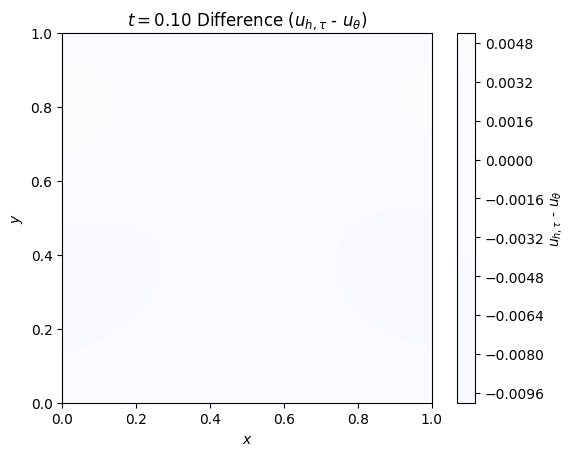

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import dolfin as df
from typing import Dict, List

EXACT = 'exact'
FEM = 'fem'
PINN = 'pinn'

def plot_2d_heatmap(
    solution_dict: Dict[str, np.array],
    function_space: df.FunctionSpace,
    time_mesh: np.array,
    levels: List[int],
    folder_path: str  # Added parameter for saving plots
) -> None:
    """
    Plots exact and numerical solutions of 2D heat equation as a 2D heatmap for different times t.
    Also calculates and prints the correlation between EXACT and PINN solutions.

    :param solution_dict:       Dict of exact and numerical solutions as numpy arrays.
    :param function_space:      Finite element function space from FEM solution.
    :param time_mesh:           Different time steps from FEM solution as numpy array.
    :param levels:              List of time indexes to plot the solutions.
    :param folder_path:         Location for saving the figures to.
    :return:                    None
    """
    # Define labels for the solutions
    name_dict = {EXACT: "$u$", FEM: r"$u_{h,\tau}$", PINN: r"$u_{\theta}$"}

    # Compute min and max values of the solutions for setting the color bar limits
    solution_min = np.min(list(solution_dict.values()))
    solution_max = np.max(list(solution_dict.values()))

    # Compute differences
    diff_exact_pinn = solution_dict[EXACT] - solution_dict[PINN]
    diff_fem_pinn = solution_dict[FEM] - solution_dict[PINN]

    # Calculate correlation between EXACT and PINN
    correlation_exact_pinn = np.corrcoef(solution_dict[EXACT].ravel(), solution_dict[PINN].ravel())[0, 1]
    print(f"Correlation between EXACT and PINN solutions: {correlation_exact_pinn:.4f}")

    # Time-stepping and iterating over the different solutions
    for name, solution in [(EXACT, diff_exact_pinn), (FEM, diff_fem_pinn)]:
        for step in levels:
            solution_function = df.Function(function_space)
            solution_function.vector().set_local(solution[step, :])

            # Plot solution difference
            plt.clf()
            heatmap = df.plot(
                solution_function,
                title=f"$t = {time_mesh[step]:.2f}$ Difference ({name_dict[name]} - {name_dict[PINN]})",
                cmap="bwr",  # Red for positive, blue for negative
                vmin=-np.max(np.abs(solution_min)),  # Symmetric about 0
                vmax=np.max(np.abs(solution_max))
            )

            # Finalize and save the plot
            plt.colorbar(heatmap, label=f"{name_dict[name]} - {name_dict[PINN]}")
            plt.xlabel(r"$x$")
            plt.ylabel(r"$y$")
            plt.savefig(f"{folder_path}/plot_{name}_vs_pinn_t{step}.png")

# Assuming these variables are defined earlier in your code
sol = np.load('/home/hpcs_rnd/RAVINDRA_IISc/heat_equation/data_2d/solution_all_2d.npz')
exact_solution = sol['exact_solution']
solution_pinn = sol['solution_pinn']
solution_fem = sol['solution_fem']


# Specify the folder path where plots will be saved
folder_path = '/home/hpcs_rnd/RAVINDRA_IISc/heat_equation/plot_2d'

# Call the modified function
plot_2d_heatmap(
    {
        EXACT: exact_solution,
        FEM: solution_fem,
        PINN: solution_pinn
    },
    function_space,
    time_values_data,
    [0, 50, 100],
    folder_path
)


In [15]:
import numpy as np
import dolfin as df
from typing import Dict

EXACT = 'exact'
PINN = 'pinn'

def calculate_correlation(exact_solution: np.array, pinn_solution: np.array) -> float:
    """
    Calculate correlation between EXACT and PINN solutions.

    :param exact_solution:      Exact solution as numpy array.
    :param pinn_solution:       PINN solution as numpy array.
    :return:                    Pearson correlation coefficient.
    """
    return np.corrcoef(exact_solution.ravel(), pinn_solution.ravel())[0, 1]

def calculate_comparison_metrics(exact_solution: np.array, pinn_solution: np.array) -> Dict[str, float]:
    """
    Calculate comparison metrics between EXACT and PINN solutions.

    :param exact_solution:      Exact solution as numpy array.
    :param pinn_solution:       PINN solution as numpy array.
    :return:                    Dictionary with metrics: {'mae': float, 'rmse': float, 're': float, 'r_squared': float}
    """
    # Flatten arrays for computation
    exact_flat = exact_solution.ravel()
    pinn_flat = pinn_solution.ravel()

    # Mean Absolute Error (MAE)
    mae = np.mean(np.abs(exact_flat - pinn_flat))

    # Root Mean Squared Error (RMSE)
    rmse = np.sqrt(np.mean((exact_flat - pinn_flat)**2))

    # Relative Error (RE)
    re = rmse / np.mean(np.abs(exact_flat))

    # Coefficient of Determination (R-squared)
    exact_mean = np.mean(exact_flat)
    ss_total = np.sum((exact_flat - exact_mean)**2)
    ss_residual = np.sum((exact_flat - pinn_flat)**2)
    r_squared = 1.0 - (ss_residual / ss_total)

    return {'mae': mae, 'rmse': rmse, 're': re, 'r_squared': r_squared}

# Example usage:
# Assuming these variables are defined earlier in your code
sol = np.load('/home/hpcs_rnd/RAVINDRA_IISc/heat_equation/data_2d/solution_all_2d.npz')
exact_solution = sol['exact_solution']
solution_pinn = sol['solution_pinn']

# Calculate correlation
correlation_exact_pinn = calculate_correlation(exact_solution, solution_pinn)
print(f"Correlation between EXACT and PINN solutions: {correlation_exact_pinn:.4f}")

# Calculate comparison metrics
metrics_exact_pinn = calculate_comparison_metrics(exact_solution, solution_pinn)
print(f"Comparison metrics between EXACT and PINN solutions:")
print(f"MAE: {metrics_exact_pinn['mae']:.4f}")
print(f"RMSE: {metrics_exact_pinn['rmse']:.4f}")
print(f"Relative Error (RE): {metrics_exact_pinn['re']:.4f}")
print(f"R-squared: {metrics_exact_pinn['r_squared']:.4f}")


Correlation between EXACT and PINN solutions: 0.9802
Comparison metrics between EXACT and PINN solutions:
MAE: 0.0224
RMSE: 0.0367
Relative Error (RE): 0.3522
R-squared: 0.9603


In [16]:
import numpy as np
import dolfin as df
from typing import Dict

EXACT = 'exact'
FEM = 'fem'

def calculate_comparison_metrics(exact_solution: np.array, fem_solution: np.array) -> Dict[str, float]:
    """
    Calculate comparison metrics between EXACT and FEM solutions.

    :param exact_solution:      Exact solution as numpy array.
    :param fem_solution:        FEM solution as numpy array.
    :return:                    Dictionary with metrics: {'mae': float, 'rmse': float, 're': float, 'r_squared': float}
    """
    # Flatten arrays for computation
    exact_flat = exact_solution.ravel()
    fem_flat = fem_solution.ravel()

    # Mean Absolute Error (MAE)
    mae = np.mean(np.abs(exact_flat - fem_flat))

    # Root Mean Squared Error (RMSE)
    rmse = np.sqrt(np.mean((exact_flat - fem_flat)**2))

    # Relative Error (RE)
    re = rmse / np.mean(np.abs(exact_flat))

    # Coefficient of Determination (R-squared)
    exact_mean = np.mean(exact_flat)
    ss_total = np.sum((exact_flat - exact_mean)**2)
    ss_residual = np.sum((exact_flat - fem_flat)**2)
    r_squared = 1.0 - (ss_residual / ss_total)

    return {'mae': mae, 'rmse': rmse, 're': re, 'r_squared': r_squared}

# Example usage:
# Assuming these variables are defined earlier in your code
sol = np.load('/home/hpcs_rnd/RAVINDRA_IISc/heat_equation/data_2d/solution_all_2d.npz')
exact_solution = sol['exact_solution']
solution_fem = sol['solution_fem']

# Calculate comparison metrics
metrics_exact_fem = calculate_comparison_metrics(exact_solution, solution_fem)
print(f"Comparison metrics between EXACT and FEM solutions:")
print(f"MAE: {metrics_exact_fem['mae']:.4f}")
print(f"RMSE: {metrics_exact_fem['rmse']:.4f}")
print(f"Relative Error (RE): {metrics_exact_fem['re']:.4f}")
print(f"R-squared: {metrics_exact_fem['r_squared']:.4f}")


Comparison metrics between EXACT and FEM solutions:
MAE: 0.0007
RMSE: 0.0011
Relative Error (RE): 0.0108
R-squared: 1.0000
